# Pilotstudie (überholter Stand)

Dieses Notebook dokumentiert die ursprüngliche Analyse mit zwei Unternehmen
(AMD, Nvidia). Es ist **nicht der Stand der Bachelorarbeit** und wird hier
ausschließlich zur Nachvollziehbarkeit der in Kapitel 5 diskutierten
Pilotbefunde bereitgestellt.

Bekannte Abweichungen zur finalen Analyse:
- Die Treibhausgasintensität wird als berichteter Wert übernommen statt aus
  Scope 1, Scope 2 und Umsatz berechnet (vgl. Abschnitt 3.2.4 der Arbeit).
- Die Metrikliste enthält Kennzahlen, die in der finalen Analyse wegen
  fehlender Vergleichbarkeit ausgeschlossen wurden.
- Die Lag-Analyse ist als gelaggte Fixed-Effects-Regression implementiert,
  nicht als Lag-Korrelation.
- Es wird keine Korrektur für multiples Testen angewendet.

Die finale Analyse befindet sich in `04_multicompany.ipynb`.

#### Cell 1 - Load both datasets:

In [4]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


COMPANY = "nvidia" # "amd" / "nvidia"
# Load sentiment data
sentiment_df = pd.read_csv("../data/processed/" + COMPANY + "_scored.csv")

# Load ESG data
esg_df = pd.read_excel("../data/raw/Nvidia_esg_CLEANUP.xlsx")

print(f"Sentiment: {len(sentiment_df)} reviews, years {sentiment_df['year'].min()}-{sentiment_df['year'].max()}")
print(f"ESG: {len(esg_df)} metric-year rows, {esg_df['metric_name'].nunique()} metrics")
print(f"ESG years: {sorted(esg_df['year'].unique())}")

Sentiment: 2196 reviews, years 2019-2024
ESG: 255 metric-year rows, 51 metrics
ESG years: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


#### Cell 2 - Aggregate sentiment by year:

In [5]:
# Aggregate sentiment scores to yearly level
yearly_sentiment = sentiment_df.groupby("year").agg(
    n_reviews=("roberta_score", "count"),
    mean_roberta=("roberta_score", "mean"),
    median_roberta=("roberta_score", "median"),
    std_roberta=("roberta_score", "std"),
    mean_vader=("vader_score", "mean"),
    mean_siebert=("siebert_score", "mean"),
    mean_stars=("overall_stars", "mean"),
    pct_negative=("sentiment_label", lambda x: (x == "negative").mean()),
    pct_neutral=("sentiment_label", lambda x: (x == "neutral").mean()),  # NEU
    pct_positive=("sentiment_label", lambda x: (x == "positive").mean()),  # NEU
    mean_roberta_pros=("roberta_pros_score", "mean"),
    mean_roberta_cons=("roberta_cons_score", "mean"),
).reset_index()


print("Yearly sentiment summary:")
print(yearly_sentiment.to_string(index=False))

Yearly sentiment summary:
 year  n_reviews  mean_roberta  median_roberta  std_roberta  mean_vader  mean_siebert  mean_stars  pct_negative  pct_neutral  pct_positive  mean_roberta_pros  mean_roberta_cons
 2019        197      0.745414        0.887549     0.360930    0.752198      0.907204    4.548223      0.035533     0.035533      0.928934           0.801126          -0.299966
 2020        223      0.762994        0.904145     0.361924    0.757043      0.917727    4.614350      0.022422     0.049327      0.928251           0.830180          -0.281390
 2021        491      0.755433        0.887507     0.328570    0.719266      0.937644    4.586558      0.036660     0.026477      0.936864           0.823049          -0.252186
 2022        379      0.730683        0.882940     0.375339    0.674118      0.898260    4.583113      0.031662     0.044855      0.923483           0.823119          -0.265689
 2023        407      0.749073        0.883735     0.352821    0.698825      0.924514    

#### Cell 3 - Pivot ESG data to wide format (one row per year, one column per metric):

In [6]:
# Convert values to numeric
esg_df["value_num"] = pd.to_numeric(esg_df["value"], errors="coerce")

# Pivot: rows = years, columns = metric names
esg_wide = esg_df.pivot_table(
    index="year", columns="metric_name", values="value_num", aggfunc="first"
)

# Also keep pillar mapping for later grouping
pillar_map = esg_df.drop_duplicates("metric_name").set_index("metric_name")["pillar"].to_dict()

print(f"ESG wide shape: {esg_wide.shape}")
print(f"\nMetrics per pillar:")
for pillar in ["Environment", "Social", "Governance"]:
    metrics = [m for m, p in pillar_map.items() if p == pillar]
    print(f"  {pillar}: {len(metrics)} metrics")

print(f"\nMissing values per year:")
print(esg_wide.isna().sum(axis=1))

ESG wide shape: (5, 42)

Metrics per pillar:
  Environment: 17 metrics
  Social: 17 metrics
  Governance: 16 metrics

Missing values per year:
year
2020    7
2021    4
2022    2
2023    3
2024    4
dtype: int64


#### Cell 4 - Merge sentiment and ESG into one panel:

In [7]:
# Merge on year
panel = yearly_sentiment.merge(esg_wide, on="year", how="inner")

print(f"Panel: {len(panel)} years with both sentiment and ESG data")
print(f"Years: {sorted(panel['year'].tolist())}")
print(f"Columns: {len(panel.columns)}")

Panel: 5 years with both sentiment and ESG data
Years: [2020, 2021, 2022, 2023, 2024]
Columns: 55


#### Cell 5 - Compute correlations between sentiment and each ESG metric:

In [8]:
# Get all numeric ESG metric columns (exclude sentiment columns)
sentiment_cols = [
    "n_reviews", "mean_roberta", "median_roberta", "std_roberta",
    "mean_vader", "mean_siebert", "mean_stars", 
    "pct_negative", "pct_neutral", "pct_positive",
    "mean_roberta_pros", "mean_roberta_cons"
]
esg_metrics = [c for c in panel.columns if c not in sentiment_cols + ["year"]]

# Primary sentiment measure
primary_sentiment = "mean_roberta"

# Compute correlations
results = []
for metric in esg_metrics:
    # Drop years where either value is missing
    valid = panel[[primary_sentiment, metric]].dropna()
    n = len(valid)
    
    if n >= 4:  # need at least 4 points for meaningful correlation
        r_pearson, p_pearson = pearsonr(valid[primary_sentiment], valid[metric])
        r_spearman, p_spearman = spearmanr(valid[primary_sentiment], valid[metric])
        
        results.append({
            "metric": metric,
            "pillar": pillar_map.get(metric, "Unknown"),
            "n_years": n,
            "pearson_r": round(r_pearson, 3),
            "pearson_p": round(p_pearson, 4),
            "spearman_r": round(r_spearman, 3),
            "spearman_p": round(p_spearman, 4),
            "direction": "positive" if r_pearson > 0 else "negative"
        })
    else:
        results.append({
            "metric": metric,
            "pillar": pillar_map.get(metric, "Unknown"),
            "n_years": n,
            "pearson_r": np.nan,
            "pearson_p": np.nan,
            "spearman_r": np.nan,
            "spearman_p": np.nan,
            "direction": "insufficient data"
        })

corr_df = pd.DataFrame(results).sort_values("pearson_r", ascending=False)

print("Correlations between mean RoBERTa sentiment and ESG metrics:")
print("=" * 85)
print(f"{'Metric':<35} {'Pillar':<14} {'n':>2} {'Pearson r':>10} {'p-val':>8} {'Spearman r':>11}")
print("-" * 85)
for _, row in corr_df.iterrows():
    if pd.notna(row['pearson_r']):
        sig = "*" if row['pearson_p'] < 0.1 else " "
        print(f"{row['metric']:<35} {row['pillar']:<14} {row['n_years']:>2} {row['pearson_r']:>+10.3f} {row['pearson_p']:>8.4f}{sig} {row['spearman_r']:>+10.3f}")
    else:
        print(f"{row['metric']:<35} {row['pillar']:<14} {row['n_years']:>2}       insufficient data")

Correlations between mean RoBERTa sentiment and ESG metrics:
Metric                              Pillar          n  Pearson r    p-val  Spearman r
-------------------------------------------------------------------------------------
Say-on-Pay Approval                 Governance      5     +0.873   0.0531*     +0.667
GHG Intensity                       Environment     5     +0.835   0.0781*     +0.900
Employee Turnover Rate              Social          5     +0.768   0.1296      +0.700
Scope 2 Market-Based                Environment     5     +0.742   0.1507      +0.500
Total Recordable Injury Rate        Social          5     +0.531   0.3575      +0.821
Total Waste Generated               Environment     5     +0.336   0.5807      +0.700
Waste Recycled/Diverted             Environment     5     +0.305   0.6179      +0.700
E-Waste Recycling Rate              Environment     5     +0.246   0.6902      +0.100
Independent Directors               Governance      5     +0.071   0.9091      

#### Cell 5B - Add Kendall's τ to correlation analysis:

In [9]:
from scipy.stats import kendalltau

# Use the same variables defined in Cell 5
# primary_sentiment = "mean_roberta" (already defined)
# pillar_map (already defined in Cell 3)

comparison_results = []

for metric in esg_metrics:
    valid = panel[[primary_sentiment, metric]].dropna()
    n = len(valid)
    
    if n >= 4:
        r_pearson, p_pearson = pearsonr(valid[primary_sentiment], valid[metric])
        r_spearman, p_spearman = spearmanr(valid[primary_sentiment], valid[metric])
        r_kendall, p_kendall = kendalltau(valid[primary_sentiment], valid[metric])
        
        comparison_results.append({
            "metric": metric,
            "pillar": pillar_map.get(metric, "Unknown"),
            "n": n,
            "pearson_r": round(r_pearson, 3),
            "spearman_r": round(r_spearman, 3),
            "kendall_tau": round(r_kendall, 3),
            "methods_agree": (
                "YES" if (r_pearson > 0 and r_spearman > 0 and r_kendall > 0)
                or (r_pearson < 0 and r_spearman < 0 and r_kendall < 0)
                else "NO"
            )
        })

comp_df = pd.DataFrame(comparison_results).sort_values("pearson_r", key=abs, ascending=False)

print("Three-method correlation comparison:")
print("=" * 95)
print(f"{'Metric':<35} {'Pillar':<14} {'Pearson':>8} {'Spearman':>9} {'Kendall':>8} {'Agree?':>7}")
print("-" * 95)
for _, row in comp_df.iterrows():
    print(f"{row['metric']:<35} {row['pillar']:<14} {row['pearson_r']:>+8.3f} {row['spearman_r']:>+9.3f} {row['kendall_tau']:>+8.3f} {row['methods_agree']:>7}")

agree_pct = (comp_df["methods_agree"] == "YES").mean() * 100
print(f"\nMethods agree on direction: {agree_pct:.0f}% of metrics")

Three-method correlation comparison:
Metric                              Pillar          Pearson  Spearman  Kendall  Agree?
-----------------------------------------------------------------------------------------------
Renewable Energy Consumption        Environment      -0.960    -0.800   -0.600     YES
Women on Board                      Governance       -0.957    -0.894   -0.837     YES
Women in Senior Management          Social           -0.943    -1.000   -1.000     YES
Renewable Energy Percentage         Environment      -0.939    -0.800   -0.600     YES
Total Revenue                       Component        -0.918    -0.900   -0.800     YES
Women in Workforce                  Social           -0.914    -0.700   -0.600     YES
CEO Pay Ratio                       Governance       -0.875    -1.000   -1.000     YES
Say-on-Pay Approval                 Governance       +0.873    +0.667   +0.527     YES
Female Directors                    Governance       -0.868    -0.894   -0.837     Y

#### Cell 6 - Summary by pillar (direction counts):


In [10]:
# For each pillar, how many metrics correlate positively vs negatively?
valid_corr = corr_df[corr_df["pearson_r"].notna()].copy()

print("\nDirection of correlation by ESG pillar:")
print("=" * 60)
for pillar in ["Environment", "Social", "Governance"]:
    subset = valid_corr[valid_corr["pillar"] == pillar]
    if len(subset) > 0:
        pos = (subset["direction"] == "positive").sum()
        neg = (subset["direction"] == "negative").sum()
        mean_r = subset["pearson_r"].mean()
        print(f"\n  {pillar}:")
        print(f"    {pos} positive / {neg} negative correlations")
        print(f"    Mean Pearson r: {mean_r:+.3f}")
        print(f"    Strongest: {subset.iloc[0]['metric']} (r={subset.iloc[0]['pearson_r']:+.3f})")
        print(f"    Weakest:   {subset.iloc[-1]['metric']} (r={subset.iloc[-1]['pearson_r']:+.3f})")


Direction of correlation by ESG pillar:

  Environment:
    5 positive / 8 negative correlations
    Mean Pearson r: -0.215
    Strongest: GHG Intensity (r=+0.835)
    Weakest:   Renewable Energy Consumption (r=-0.960)

  Social:
    2 positive / 8 negative correlations
    Mean Pearson r: -0.409
    Strongest: Employee Turnover Rate (r=+0.768)
    Weakest:   Women in Senior Management (r=-0.943)

  Governance:
    4 positive / 4 negative correlations
    Mean Pearson r: -0.303
    Strongest: Say-on-Pay Approval (r=+0.873)
    Weakest:   Women on Board (r=-0.957)


#### Cell 7 - Lagged correlation (sentiment in year t vs ESG in year t+1):


In [11]:
# Does employee sentiment PREDICT next year's ESG metrics?
lagged_results = []

for metric in esg_metrics:
    # Shift sentiment back by 1 year (sentiment_t vs esg_t+1)
    lag_df = panel[["year", primary_sentiment, metric]].copy()
    lag_df["sentiment_lag1"] = lag_df[primary_sentiment].shift(1)
    lag_valid = lag_df[["sentiment_lag1", metric]].dropna()
    
    n = len(lag_valid)
    if n >= 4:
        r, p = pearsonr(lag_valid["sentiment_lag1"], lag_valid[metric])
        lagged_results.append({
            "metric": metric,
            "pillar": pillar_map.get(metric, "Unknown"),
            "n_years": n,
            "lag1_pearson_r": round(r, 3),
            "lag1_pearson_p": round(p, 4),
        })

lag_df_results = pd.DataFrame(lagged_results).sort_values("lag1_pearson_r", ascending=False)

print("Lagged correlations: sentiment(t) → ESG metric(t+1)")
print("=" * 75)
print(f"{'Metric':<35} {'Pillar':<14} {'n':>2} {'Lag1 r':>10} {'p-val':>8}")
print("-" * 75)
for _, row in lag_df_results.iterrows():
    sig = "*" if row['lag1_pearson_p'] < 0.1 else " "
    print(f"{row['metric']:<35} {row['pillar']:<14} {row['n_years']:>2} {row['lag1_pearson_r']:>+10.3f} {row['lag1_pearson_p']:>8.4f}{sig}")

Lagged correlations: sentiment(t) → ESG metric(t+1)
Metric                              Pillar          n     Lag1 r    p-val
---------------------------------------------------------------------------
Total Recordable Injury Rate        Social          4     +0.831   0.1693 
Scope 2 Market-Based                Environment     4     +0.563   0.4374 
GHG Intensity                       Environment     4     +0.521   0.4787 
Green Building Certifications       Environment     4     +0.384   0.6159 
Effective Tax Rate                  Governance      4     +0.367   0.6334 
Waste Recycled/Diverted             Environment     4     +0.298   0.7025 
Water Withdrawal                    Environment     4     +0.257   0.7430 
Total Waste Generated               Environment     4     +0.207   0.7935 
Women in Senior Management          Social          4     +0.040   0.9596 
Board Size                          Governance      4     +0.023   0.9772 
Independent Directors               Governance  

#### Cell 8 - Visualize the most interesting relationships:


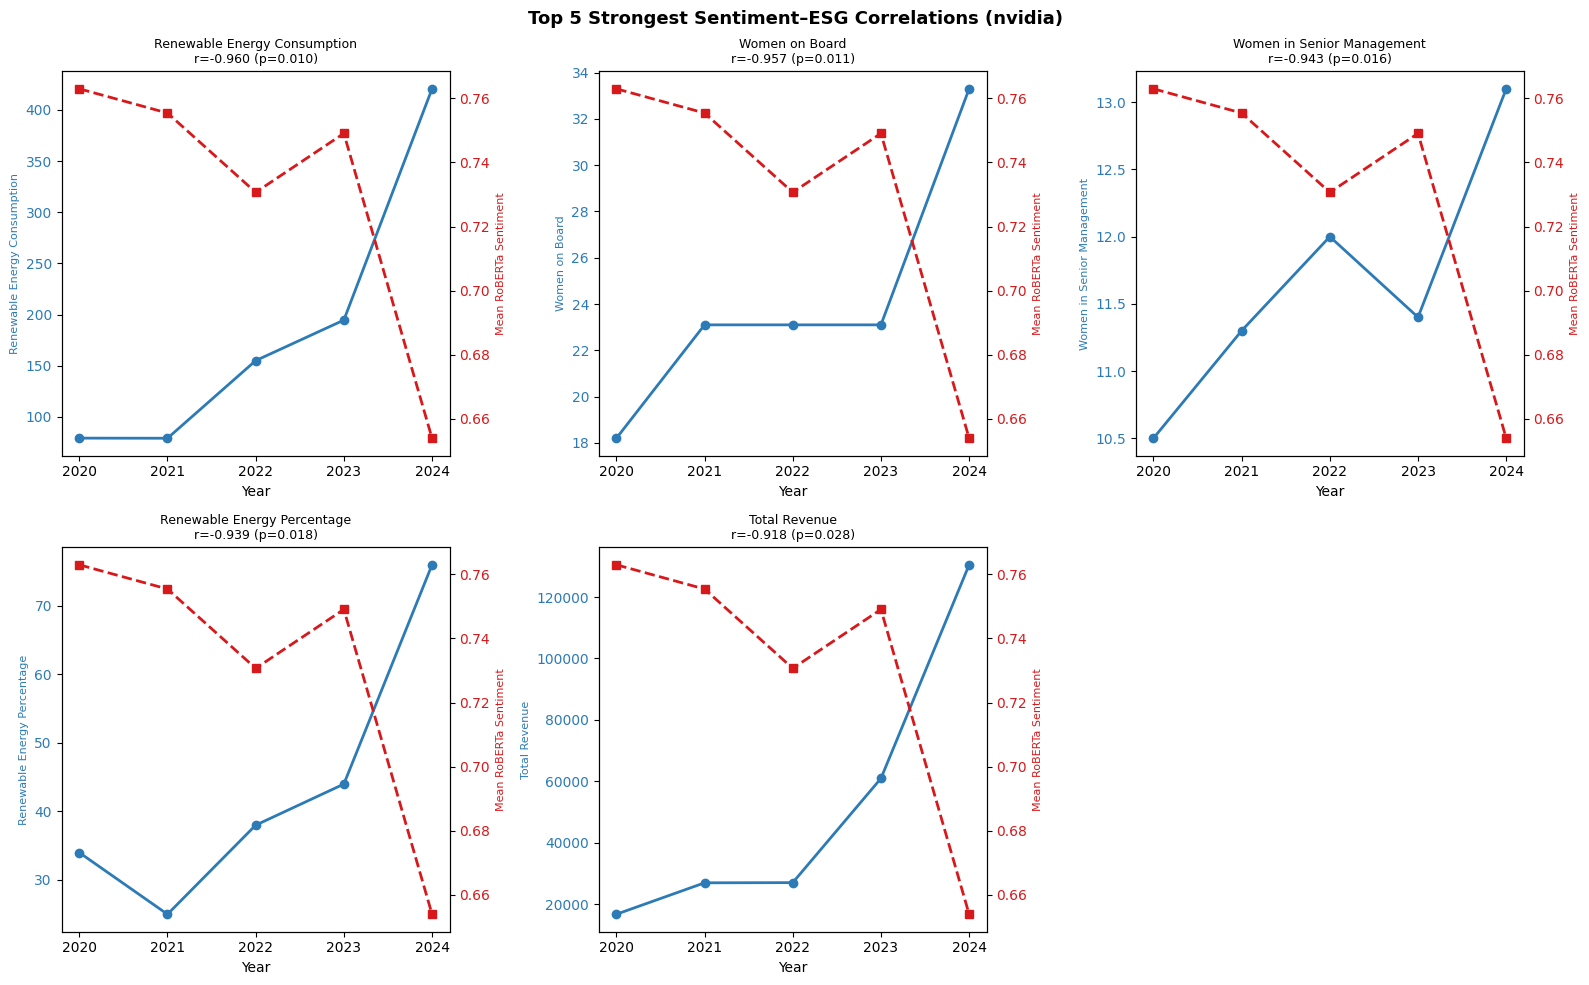

In [12]:
# Pick top 5 strongest correlations (by absolute Pearson r)
top_metrics = valid_corr.reindex(valid_corr["pearson_r"].abs().sort_values(ascending=False).index).head(5)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (_, row) in enumerate(top_metrics.iterrows()):
    ax = axes[i]
    metric = row["metric"]
    
    plot_data = panel[["year", primary_sentiment, metric]].dropna()
    
    # Dual axis: ESG metric on left, sentiment on right
    color_esg = "#2c7bb6"
    color_sent = "#d7191c"
    
    ax.plot(plot_data["year"], plot_data[metric], "o-", color=color_esg, label=metric, linewidth=2)
    ax.set_ylabel(metric, color=color_esg, fontsize=8)
    ax.tick_params(axis="y", labelcolor=color_esg)
    
    ax2 = ax.twinx()
    ax2.plot(plot_data["year"], plot_data[primary_sentiment], "s--", color=color_sent, label="Sentiment", linewidth=2)
    ax2.set_ylabel("Mean RoBERTa Sentiment", color=color_sent, fontsize=8)
    ax2.tick_params(axis="y", labelcolor=color_sent)
    
    ax.set_title(f"{metric}\nr={row['pearson_r']:+.3f} (p={row['pearson_p']:.3f})", fontsize=9)
    ax.set_xlabel("Year")
    ax.set_xticks(plot_data["year"])

# Hide unused subplot
axes[5].axis("off")

plt.suptitle("Top 5 Strongest Sentiment–ESG Correlations (" + COMPANY + ")", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../results/" + COMPANY + "_top5_correlations.png", dpi=150, bbox_inches="tight")
plt.show()

#### Cell 9 - Correlation heatmap across all sentiment measures:


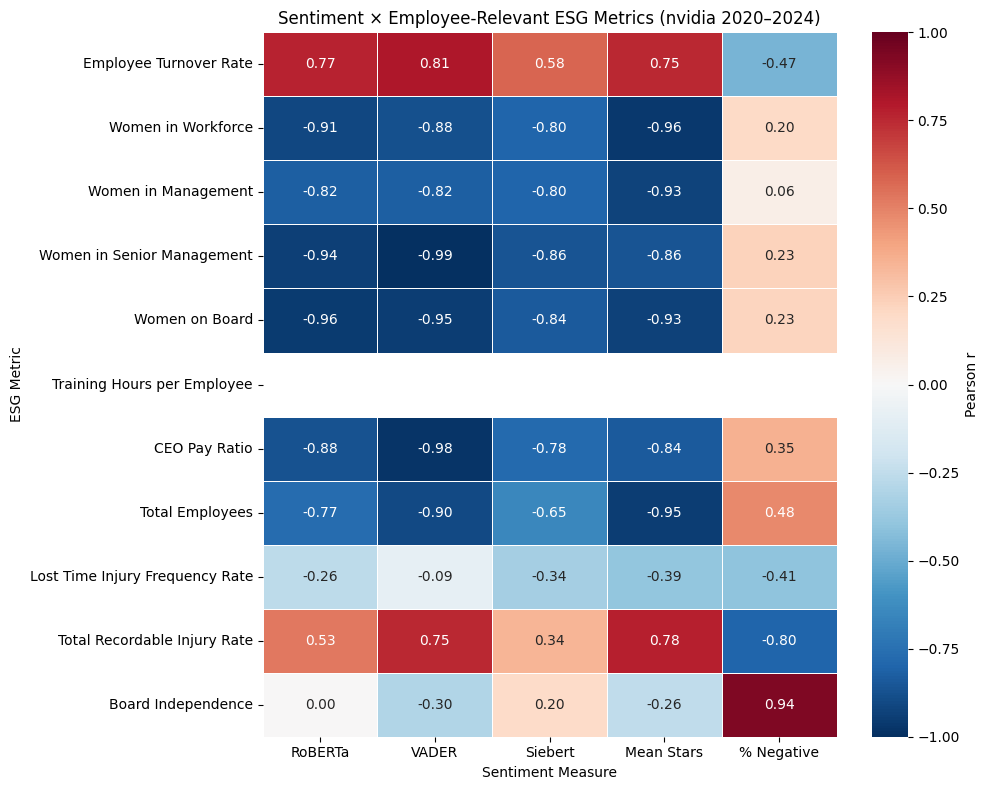

In [13]:
# Cross-correlate multiple sentiment measures with employee-relevant ESG metrics
employee_relevant = [
    "Employee Turnover Rate", "Women in Workforce", "Women in Management",
    "Women in Senior Management", "Women on Board", "Training Hours per Employee",
    "CEO Pay Ratio", "Total Employees", "Lost Time Injury Frequency Rate",
    "Total Recordable Injury Rate", "Board Independence"
]

# Keep only metrics that exist in the panel
available = [m for m in employee_relevant if m in panel.columns]

sent_measures = ["mean_roberta", "mean_vader", "mean_siebert", "mean_stars", "pct_negative"]
sent_labels = ["RoBERTa", "VADER", "Siebert", "Mean Stars", "% Negative"]

# Build correlation matrix
corr_matrix = pd.DataFrame(index=available, columns=sent_labels)

for metric in available:
    for sent_col, sent_label in zip(sent_measures, sent_labels):
        valid = panel[[sent_col, metric]].dropna()
        if len(valid) >= 4:
            r, _ = pearsonr(valid[sent_col], valid[metric])
            corr_matrix.loc[metric, sent_label] = round(r, 3)

corr_matrix = corr_matrix.astype(float)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix, annot=True, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    fmt=".2f", linewidths=0.5, ax=ax, cbar_kws={"label": "Pearson r"}
)
ax.set_title("Sentiment × Employee-Relevant ESG Metrics (" + COMPANY + " 2020–2024)", fontsize=12)
ax.set_xlabel("Sentiment Measure")
ax.set_ylabel("ESG Metric")

plt.tight_layout()
plt.savefig("../results/" + COMPANY +"_sentiment_esg_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

#### Cell 10 - Robustness check: do all sentiment models agree?

In [14]:
# Compare model agreement on the direction of correlation
print("Model agreement on correlation direction:")
print("=" * 75)
print(f"{'Metric':<35} {'RoBERTa':>8} {'VADER':>8} {'Siebert':>8} {'Stars':>8} {'Agree?':>8}")
print("-" * 75)

for metric in available:
    directions = {}
    for sent_col, label in zip(sent_measures[:4], ["RoBERTa", "VADER", "Siebert", "Stars"]):
        valid = panel[[sent_col, metric]].dropna()
        if len(valid) >= 4:
            r, _ = pearsonr(valid[sent_col], valid[metric])
            directions[label] = "+" if r > 0 else "-"
        else:
            directions[label] = "?"
    
    signs = [v for v in directions.values() if v != "?"]
    agree = "YES" if len(set(signs)) <= 1 and len(signs) > 0 else "NO"
    
    print(f"{metric:<35} {directions.get('RoBERTa', '?'):>8} {directions.get('VADER', '?'):>8} {directions.get('Siebert', '?'):>8} {directions.get('Stars', '?'):>8} {agree:>8}")

Model agreement on correlation direction:
Metric                               RoBERTa    VADER  Siebert    Stars   Agree?
---------------------------------------------------------------------------
Employee Turnover Rate                     +        +        +        +      YES
Women in Workforce                         -        -        -        -      YES
Women in Management                        -        -        -        -      YES
Women in Senior Management                 -        -        -        -      YES
Women on Board                             -        -        -        -      YES
Training Hours per Employee                ?        ?        ?        ?       NO
CEO Pay Ratio                              -        -        -        -      YES
Total Employees                            -        -        -        -      YES
Lost Time Injury Frequency Rate            -        -        -        -      YES
Total Recordable Injury Rate               +        +        +        + 

#### Cell 11 - Save results:

In [15]:
# Save correlation tables
corr_df.to_csv("../results/" + COMPANY + "_contemporaneous_correlations.csv", index=False)
lag_df_results.to_csv("../results/" + COMPANY + "_lagged_correlations.csv", index=False)
corr_matrix.to_csv("../results/" + COMPANY + "_heatmap_correlations.csv")
panel.to_csv("../results/" + COMPANY + "_panel.csv", index=False)

print("Saved to results/:")
print("  - " + COMPANY + "_contemporaneous_correlations.csv")
print("  - " + COMPANY + "_lagged_correlations.csv")
print("  - " + COMPANY + "_heatmap_correlations.csv")
print("  - " + COMPANY + "_panel.csv")

Saved to results/:
  - nvidia_contemporaneous_correlations.csv
  - nvidia_lagged_correlations.csv
  - nvidia_heatmap_correlations.csv
  - nvidia_panel.csv
